# GLM

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import polars as pl

os.chdir("../../")
sys.path.insert(0, os.getcwd())

In [2]:
import statsmodels.api as sm

In [446]:
from morai.experience import charters, experience, tables
from morai.forecast import metrics, preprocessors
from morai.models import core
from morai.utils import custom_logger, helpers

In [4]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

## Logistic Formula

### Partial Prediction

A logistic regression is of the form:

$$
p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}
$$

Another way of writing this would be:

$$
\log\!\left(\frac{1 - p(x)}{p(x)}\right) = \beta_0 + \beta_1 x_i
$$

The odds ratio determines the increase with a value change in the variable defined as:

$$
odds = \frac{p}{1-p}
$$

If wanting to adjust a value using a base probabilty the probability first needs to be transformed to odds and then adjusted and transformed back

$$
\displaylines{
\text{base\_odds} = \frac{p}{1-p} \\
\text{adj\_odds} = \text{base\_odds} \cdot \text{new\_odds} \\
\text{new\_prob} = \frac{\text{adj\_odds}}{1 + \text{adj\_odds}}
}
$$


Creating a test dataset to show how the parameters of a glm are used.

In [5]:
# dataset where sex=1 is 111% compared to sex=1 and face=1 is 50% compared to face=0
data = {
    "sex": [0, 0, 1, 1],
    "face": [0, 1, 0, 1],
    "rate": [0.45000, 0.22500, 0.50000, 0.25000],
}
df = pd.DataFrame(data)

preprocess_dict = preprocessors.preprocess_data(
    df,
    feature_dict={
        "target": ["rate"],
        "weight": [],
        "passthrough": ["sex", "face"],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

# model the data
GLM = core.GLM()
GLM.fit(X, y)

 2025-12-20 00:27:04 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-20 00:27:04 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-20 00:27:04 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['sex', 'face', 'constant'] 
 2025-12-20 00:27:04 | morai.models.core | INFO     | fiting the model 
 2025-12-20 00:27:04 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C0ECB0CA40> family... 


In [6]:
print(GLM.model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   rate   No. Observations:                    4
Model:                            GLM   Df Residuals:                        1
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1.6432
Date:                Sat, 20 Dec 2025   Deviance:                   0.00020453
Time:                        00:27:08   Pearson chi2:                 0.000205
No. Iterations:                     4   Pseudo R-squ. (CS):            0.06201
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
constant      -0.1875      1.784     -0.105      0.9

In [7]:
odds = GLM.get_odds()
params = GLM.model.params

 2025-12-20 00:27:08 | morai.models.core | INFO     | generating odds ratio from model 


The logistic regression can be calculated using the parameters or by using the odds ratios to adjust a partial prediction and it **will be the same answer.**

In [23]:
# parameters
sex = 1
face = 1
print(f"sex odds:  {odds["sex"]:.2f}")
print(f"face odds: {odds["face"]:.2f}")

# calculate probability using logistic formula
probability = 1 / (
    1 + np.exp(-(params["constant"] + params["sex"] * sex + params["face"] * face))
)
print(f"probability:     {probability:.5f}")

# calculate probability from partial prediction
base = 1 / (1 + np.exp(-(params["constant"])))
base_odd = base / (1 - base)
sex_odd = np.exp((params["sex"]) * sex)
face_odd = np.exp((params["face"]) * face)
adj_odd = base_odd * sex_odd * face_odd
new_prob = adj_odd / (1 + adj_odd)
print(f"new_probability: {new_prob:.5f}")

sex odds:  1.19
face odds: 0.34
probability:     0.25327
new_probability: 0.25327


### Categorization Multiplier

As shown above, the GLM does not perfectly predict the rates (0.25327 instead of 0.25) as the transformed function (log odds) is not perfectly linear. When the rates are large (>0.20) the change in odds ratio is more than the change in probability.

As we saw we had the following odds ratios:

In [43]:
print(f"sex odds:  {odds["sex"]:.2f}")
print(f"face odds: {odds["face"]:.2f}")

sex odds:  1.19
face odds: 0.34


We now look at creating a multiplier for `sex` that we would apply to the rates and compare it to what the odds ratio would calculate

What we see is that the multiplier will be constant (1.19). The GLM, however, produces a multiplier that is not constant. It is lower when the rates are higher (e.g. >0.20)

In [27]:
rates = X.copy()

In [51]:
rate_table_mult, mult_table = tables.generate_table(
    model=GLM.model,
    mapping=preprocess_dict["mapping"],
    preprocess_feature_dict=preprocess_dict["feature_dict"],
    preprocess_params=preprocess_dict["params"],
    mult_features=["sex"],
    mult_method="glm",
)
tables.output_table(
    rate_table=rate_table_mult, filename="simple_glm_mults.xlsx", mult_table=mult_table
)
print(f"multiple: {mult_table['multiple'][1]:.2f}")

 2025-12-20 09:26:34 | morai.experience.tables | INFO     | generating table for model GLMResultsWrapper 
 2025-12-20 09:26:34 | morai.experience.tables | WARNING  | THIS IS EXPERIMENTAL: the multipliers most likely not match the predictions exactly from the model and is used to simplify the output. 
 2025-12-20 09:26:34 | morai.experience.tables | INFO     | creating multiplier table based on the 'glm' 
 2025-12-20 09:26:34 | morai.experience.tables | INFO     | mult_table rows: 2 
 2025-12-20 09:26:34 | morai.experience.tables | INFO     | rate_table shape: (2, 3) 
 2025-12-20 09:26:34 | morai.experience.tables | INFO     | saving table to C:\Users\johnk\Desktop\github\morai\files\rates\simple_glm_mults.xlsx 
multiple: 1.19


In [52]:
rate_table_full, _ = tables.generate_table(
    model=GLM.model,
    mapping=preprocess_dict["mapping"],
    preprocess_feature_dict=preprocess_dict["feature_dict"],
    preprocess_params=preprocess_dict["params"],
)
tables.output_table(rate_table=rate_table_full, filename="simple_glm.csv")

 2025-12-20 09:26:34 | morai.experience.tables | INFO     | generating table for model GLMResultsWrapper 
 2025-12-20 09:26:34 | morai.experience.tables | INFO     | rate_table shape: (4, 4) 
 2025-12-20 09:26:34 | morai.experience.tables | INFO     | saving table to C:\Users\johnk\Desktop\github\morai\files\rates\simple_glm.csv 


In [53]:
rates = tables.map_rates(
    df=rates, rate="simple_glm_mults", rate_filename="rate_map_example.yaml"
)
rates = tables.map_rates(
    df=rates, rate="simple_glm", rate_filename="rate_map_example.yaml"
)

 2025-12-20 09:27:05 | morai.experience.tables | INFO     | mapping rate: 'qx_simple_glm_mults' with format: 'workbook' 
 2025-12-20 09:27:05 | morai.experience.tables | WARNING  | rate: 'qx_simple_glm_mults' already exists in the DataFrame. Overwriting the rate. 
 2025-12-20 09:27:05 | morai.experience.tables | INFO     | the mapped rates are based on the following keys: ['face', 'sex'] 
 2025-12-20 09:27:05 | morai.experience.tables | INFO     | mapping rate: 'qx_simple_glm' with format: 'csv' 
 2025-12-20 09:27:05 | morai.experience.tables | WARNING  | rate: 'qx_simple_glm' already exists in the DataFrame. Overwriting the rate. 
 2025-12-20 09:27:05 | morai.experience.tables | INFO     | the mapped rates are based on the following keys: ['face', 'sex'] 


In [72]:
grouped = (
    rates.groupby(["face", "sex"])
    .agg({"qx_simple_glm_mults": "mean", "qx_simple_glm": "mean"})
    .unstack()
)
df_ratio = pd.DataFrame(
    {
        "ratio_mult": grouped["qx_simple_glm_mults"][1]
        / grouped["qx_simple_glm_mults"][0],
        "ratio_full": grouped["qx_simple_glm"][1] / grouped["qx_simple_glm"][0],
    }
)
df_ratio = df_ratio.reset_index()
print("for face=0:")
print(
    f"ratio_mult = {grouped["qx_simple_glm_mults"][1][0]:.2f} / {grouped["qx_simple_glm_mults"][0][0]:.2f}  = {grouped["qx_simple_glm_mults"][1][0] / grouped["qx_simple_glm_mults"][0][0]:.2f}"
)
print(
    f"ratio_full = {grouped["qx_simple_glm"][1][0]:.2f} / {grouped["qx_simple_glm"][0][0]:.2f} = {grouped["qx_simple_glm"][1][0] / grouped["qx_simple_glm"][0][0]:.2f}"
)
print("for face=1:")
print(
    f"ratio_mult = {grouped["qx_simple_glm_mults"][1][1]:.2f} / {grouped["qx_simple_glm_mults"][0][1]:.2f} = {grouped["qx_simple_glm_mults"][1][1] / grouped["qx_simple_glm_mults"][0][1]:.2f}"
)
print(
    f"ratio_full = {grouped["qx_simple_glm"][1][1]:.2f} / {grouped["qx_simple_glm"][0][1]:.2f} = {grouped["qx_simple_glm"][1][1] / grouped["qx_simple_glm"][0][1]:.2f}"
)

for face=0:
ratio_mult = 0.54 / 0.45  = 1.19
ratio_full = 0.50 / 0.45 = 1.10
for face=1:
ratio_mult = 0.26 / 0.22 = 1.19
ratio_full = 0.25 / 0.22 = 1.14


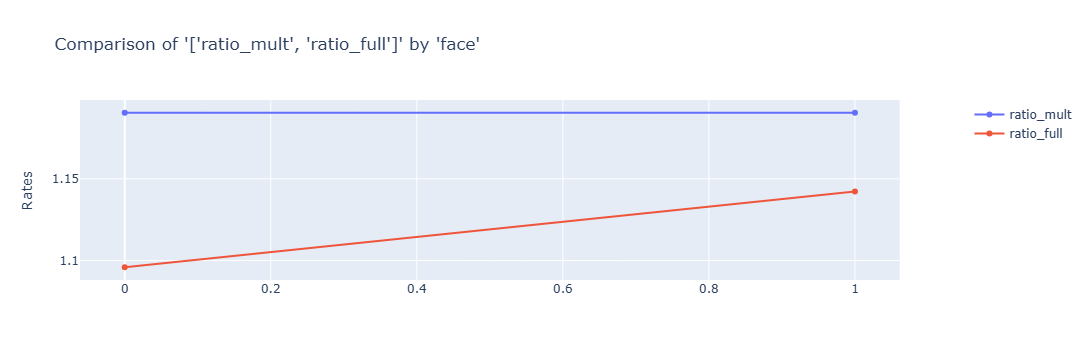

In [69]:
charters.compare_rates(df_ratio, x_axis="face", rates=["ratio_mult", "ratio_full"])

## Separate vs. Interaction Models

This is a simple example to see the impact of creating separate models for each curve or to use interaction variables. In this simple example the `old_rates` are increasing 10% each age, while the `new_rates` are increasing 5% each age.

- if you are able to perfectly separate data relationships then the model predictions will be the same between interaction and separate. If you aren't able to separate data, the `interaction` model will not be the same as a `separation` model.

A `GLM` model will produce a curve that is close to the rate of change, however it doesn't match the rate of change exactly. Conversely, as shown, a `cat` model calculates the exact curve.

In [93]:
model_data = pd.read_csv("notebooks/files/simple_data_diff_curves.csv")
model_data = model_data[["era", "age", "uw", "rate"]]

In [94]:
old_data = model_data[model_data["era"] == "old"]
new_data = model_data[model_data["era"] == "new"]

In [85]:
# interaction model
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict={
        "target": ["rate"],
        "passthrough": ["age"],
        "ohe": [
            "era",
            "uw",
        ],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
X["age_era"] = X["age"] * X["era_old"]
X["era_uw"] = X["era_old"] * X["uw_s"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

GLM = core.GLM()
GLM.fit(X, y)

predictions = GLM.model.predict(X)
model_data["interaction"] = predictions

 2025-12-20 10:14:04 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-20 10:14:04 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-20 10:14:04 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-12-20 10:14:04 | morai.forecast.preprocessors | INFO     | nominal - one hot encoded (dropping first col): ['era', 'uw'] 
 2025-12-20 10:14:04 | morai.models.core | INFO     | fiting the model 
 2025-12-20 10:14:04 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C12E6528D0> family... 


In [86]:
# separate model
for dataset, rate in [(old_data, "old"), (new_data, "new")]:
    preprocess_dict = preprocessors.preprocess_data(
        dataset,
        feature_dict={
            "target": ["rate"],
            "passthrough": ["age"],
            "ohe": [
                "uw",
            ],
        },
        standardize=False,
        add_constant=True,
    )

    X = preprocess_dict["X"]
    y = preprocess_dict["y"]
    weights = preprocess_dict["weights"]
    mapping = preprocess_dict["mapping"]

    GLM = core.GLM()
    GLM.fit(X, y)

    predictions = GLM.model.predict(X)
    model_data[rate] = predictions
model_data["separate"] = model_data["new"].combine_first(model_data["old"])
model_data = model_data.drop(columns=["new", "old"])

 2025-12-20 10:14:13 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-20 10:14:13 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-20 10:14:13 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-12-20 10:14:13 | morai.forecast.preprocessors | INFO     | nominal - one hot encoded (dropping first col): ['uw'] 
 2025-12-20 10:14:13 | morai.models.core | INFO     | fiting the model 
 2025-12-20 10:14:13 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C0ECB0D100> family... 
 2025-12-20 10:14:13 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-20 10:14:13 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-20 10:14:13 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 202

In [78]:
GLM.get_odds()

 2025-12-20 10:10:53 | morai.models.core | INFO     | generating odds ratio from model 


age         1.005367
constant    0.028809
uw_s        2.870977
dtype: float64

In [87]:
# cat model
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=1000, learning_rate=0.1, depth=7, cat_features=["uw", "era"]
)
model.fit(model_data[["age", "uw", "era"]], model_data[["rate"]], verbose=0)

predictions = model.predict(model_data[["age", "uw", "era"]])
model_data["cat"] = predictions

In [81]:
model_data["i_div_r"] = model_data["interaction"] / model_data["rate"]
model_data["s_div_r"] = model_data["separate"] / model_data["rate"]
model_data["c_div_r"] = model_data["cat"] / model_data["rate"]

The ratios show that the `cat` model has a ratio of 1 where the `glm` models have a ratio with a mean of 1 but is not constant.

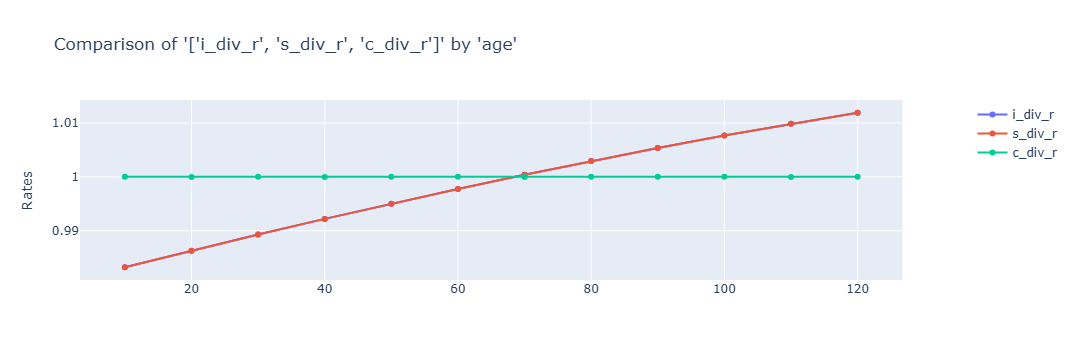

In [82]:
charters.compare_rates(
    model_data[(model_data["era"] == "new") & (model_data["uw"] == "ns")],
    x_axis="age",
    rates=["i_div_r", "s_div_r", "c_div_r"],
)

In [83]:
new = model_data[(model_data["era"] == "new") & (model_data["uw"] == "ns")]
old = model_data[(model_data["era"] == "old") & (model_data["uw"] == "ns")][
    ["era", "age", "uw", "rate"]
]
merge_new = new.merge(old, how="left", on=["age", "uw"], suffixes=["_new", "_old"])

When the `interaction` model splits out the data exactly it will match the `separate` model.

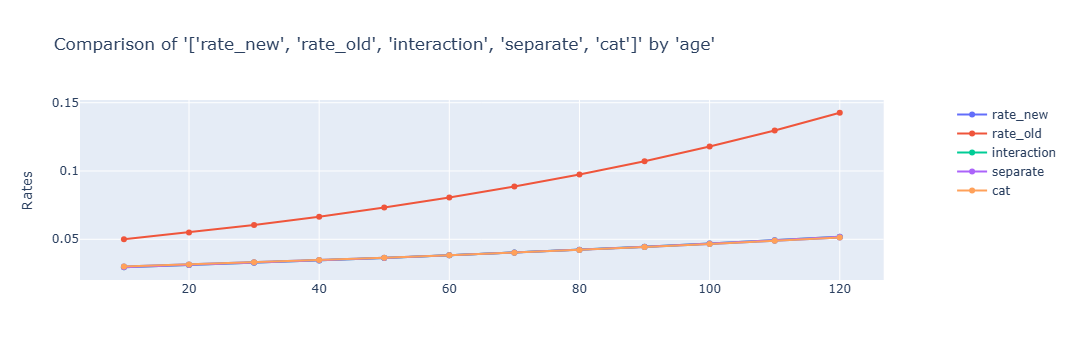

In [84]:
charters.compare_rates(
    merge_new,
    x_axis="age",
    rates=["rate_new", "rate_old", "interaction", "separate", "cat"],
)

### Extrapolating

Extrapolating rates from a model can cause incorrect conclusions.

In this example there are 2 different speeds of the rate of change.
- The `slow` speed is increasing at a constant rate of 1.10
- The `fast` speed is increasing at an increasing rate starting at 1.10 and increasing .03 every age

The experiment cuts off the data in the middle to see how the model extrapolates and what is shown for the `fast` rate is that none of the models increase at that speed.

In [140]:
model_data = pd.read_csv("notebooks/files/simple_data_diff_curve_speed.csv")
model_data = model_data[["speed", "age", "uw", "rate"]]
full_data = model_data.copy()
model_data = model_data[model_data["age"] <= 60]

In [141]:
# full data
preprocess_dict = preprocessors.preprocess_data(
    full_data,
    feature_dict={
        "target": ["rate"],
        "passthrough": ["age"],
        "ohe": [
            "speed",
            "uw",
        ],
    },
    standardize=False,
    add_constant=True,
)

X_full = preprocess_dict["X"]
X_full["age_speed"] = X_full["age"] * X_full["speed_slow"]
X_full["speed_uw"] = X_full["speed_slow"] * X_full["uw_s"]

 2025-12-20 11:36:51 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-20 11:36:51 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-20 11:36:51 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-12-20 11:36:51 | morai.forecast.preprocessors | INFO     | nominal - one hot encoded (dropping first col): ['uw', 'speed'] 


In [142]:
# interaction model
# model data
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict={
        "target": ["rate"],
        "passthrough": ["age"],
        "ohe": [
            "speed",
            "uw",
        ],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
X["age_speed"] = X["age"] * X["speed_slow"]
X["speed_uw"] = X["speed_slow"] * X["uw_s"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

GLM = core.GLM()
GLM.fit(X, y)

predictions = GLM.model.predict(X_full)
full_data["interaction"] = predictions

 2025-12-20 11:36:51 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-20 11:36:51 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-20 11:36:51 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-12-20 11:36:51 | morai.forecast.preprocessors | INFO     | nominal - one hot encoded (dropping first col): ['uw', 'speed'] 
 2025-12-20 11:36:51 | morai.models.core | INFO     | fiting the model 
 2025-12-20 11:36:51 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C12E8CE600> family... 


In [143]:
# separate model
for rate in ["slow", "fast"]:
    # model data
    preprocess_dict = preprocessors.preprocess_data(
        model_data[model_data["speed"] == rate],
        feature_dict={
            "target": ["rate"],
            "passthrough": ["age"],
            "ohe": [
                "uw",
            ],
        },
        standardize=False,
        add_constant=True,
    )

    X = preprocess_dict["X"]
    y = preprocess_dict["y"]
    weights = preprocess_dict["weights"]
    mapping = preprocess_dict["mapping"]

    GLM = core.GLM()
    GLM.fit(X, y)

    # full data
    preprocess_dict = preprocessors.preprocess_data(
        full_data[full_data["speed"] == rate],
        feature_dict={
            "target": ["rate"],
            "passthrough": ["age"],
            "ohe": [
                "uw",
            ],
        },
        standardize=False,
        add_constant=True,
    )

    X = preprocess_dict["X"]

    predictions = GLM.model.predict(X)
    full_data[rate] = predictions
full_data["separate"] = full_data["fast"].combine_first(full_data["slow"])
full_data = full_data.drop(columns=["fast", "slow"])

 2025-12-20 11:36:51 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-20 11:36:51 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-20 11:36:51 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-12-20 11:36:51 | morai.forecast.preprocessors | INFO     | nominal - one hot encoded (dropping first col): ['uw'] 
 2025-12-20 11:36:51 | morai.models.core | INFO     | fiting the model 
 2025-12-20 11:36:51 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C12E8CE600> family... 
 2025-12-20 11:36:51 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-20 11:36:51 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-20 11:36:51 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 202

In [144]:
GLM.get_odds()

 2025-12-20 11:36:51 | morai.models.core | INFO     | generating odds ratio from model 


age         1.016959
constant    0.024009
uw_s        2.899187
dtype: float64

In [145]:
# catboost model
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=1000, learning_rate=0.1, depth=7, cat_features=["uw", "speed"]
)
model.fit(model_data[["age", "uw", "speed"]], model_data[["rate"]], verbose=0)

predictions = model.predict(full_data[["age", "uw", "speed"]])
full_data["cat"] = predictions

As can be seen the models predict the rates well up to age 60 then the difference diverges.

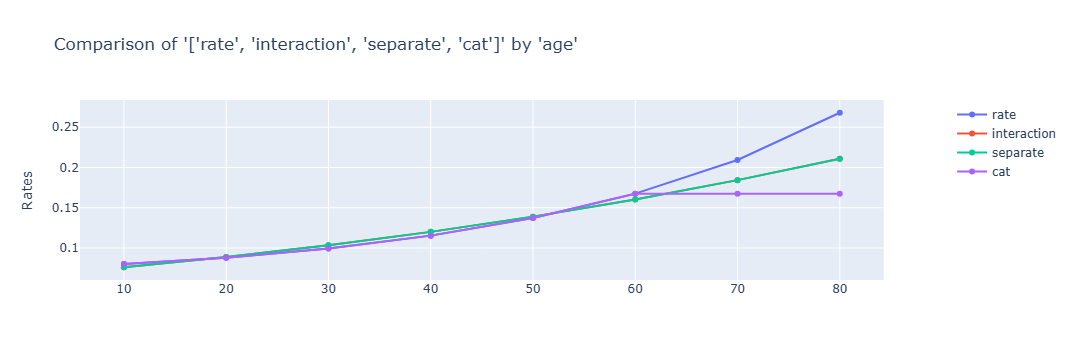

In [146]:
fast = full_data[
    (full_data["speed"] == "fast") & (full_data["uw"] == "s") & (full_data["age"] <= 80)
]
charters.compare_rates(
    fast,
    x_axis="age",
    rates=["rate", "interaction", "separate", "cat"],
)

### Blending

When data from one model runs out the data the model will use the data from other data unless it is split out perfectly.

In this experiment the test is similar to the extrapolating test. The example will remove ages above 80 in the `new` data and that model will then use information from the `old` data at those ages.

In this test:
- `new` rates increase by 1.17
- `old` rates increase by 1.10
- there isn't an interaction of era * age. This would separate the data to have same predictions as `separate`


In [172]:
model_data = pd.read_csv("notebooks/files/simple_data_easy.csv")
model_data = model_data[["era", "age", "rate"]]
full_data = model_data.copy()
model_data = model_data[
    ((model_data["era"] == "new") & (model_data["age"] <= 80))
    | (model_data["era"] == "old")
]

In [173]:
old_data = model_data[model_data["era"] == "old"]
new_data = model_data[model_data["era"] == "new"]

In [174]:
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict={
        "target": ["rate"],
        "passthrough": ["age"],
        "ohe": [
            "era",
        ],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
# X["age_era"] = X["age"] * X["era_old"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

GLM = core.GLM()
GLM.fit(X, y)

# full data
preprocess_dict = preprocessors.preprocess_data(
    full_data,
    feature_dict={
        "target": ["rate"],
        "passthrough": ["age"],
        "ohe": [
            "era",
        ],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
# X["age_era"] = X["age"] * X["era_old"]

predictions = GLM.model.predict(X)
full_data["interaction"] = predictions

 2025-12-20 12:01:29 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-20 12:01:29 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-20 12:01:29 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-12-20 12:01:29 | morai.forecast.preprocessors | INFO     | nominal - one hot encoded (dropping first col): ['era'] 
 2025-12-20 12:01:29 | morai.models.core | INFO     | fiting the model 
 2025-12-20 12:01:29 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C12E96D880> family... 
 2025-12-20 12:01:29 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-20 12:01:29 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-20 12:01:29 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 20

In [175]:
for rate in ["old", "new"]:
    # model data
    preprocess_dict = preprocessors.preprocess_data(
        model_data[model_data["era"] == rate],
        feature_dict={
            "target": ["rate"],
            "passthrough": ["age"],
            "ohe": [],
        },
        standardize=False,
        add_constant=True,
    )

    X = preprocess_dict["X"]
    y = preprocess_dict["y"]
    weights = preprocess_dict["weights"]
    mapping = preprocess_dict["mapping"]

    GLM = core.GLM()
    GLM.fit(X, y)

    # full data
    preprocess_dict = preprocessors.preprocess_data(
        full_data[full_data["era"] == rate],
        feature_dict={
            "target": ["rate"],
            "passthrough": ["age"],
            "ohe": [],
        },
        standardize=False,
        add_constant=True,
    )

    X = preprocess_dict["X"]

    predictions = GLM.model.predict(X)
    full_data[rate] = predictions
full_data["separate"] = full_data["new"].combine_first(full_data["old"])
full_data = full_data.drop(columns=["new", "old"])

 2025-12-20 12:01:30 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-20 12:01:30 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-20 12:01:30 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-12-20 12:01:30 | morai.models.core | INFO     | fiting the model 
 2025-12-20 12:01:30 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C12E96D880> family... 
 2025-12-20 12:01:30 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-20 12:01:30 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-20 12:01:30 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-12-20 12:01:30 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-20 12:01:30 | morai.forecas

In [176]:
new = full_data[(full_data["era"] == "new")]
old = full_data[(full_data["era"] == "old")][["era", "age", "rate"]]
merge_new = new.merge(old, how="left", on=["age"], suffixes=["_new", "_old"])

As seen the new rates in the `interaction` model have a slope similar to the `old` model as there is more data that is being used in the prediction. When the data is separated the predictions are similar to the `new` rates.

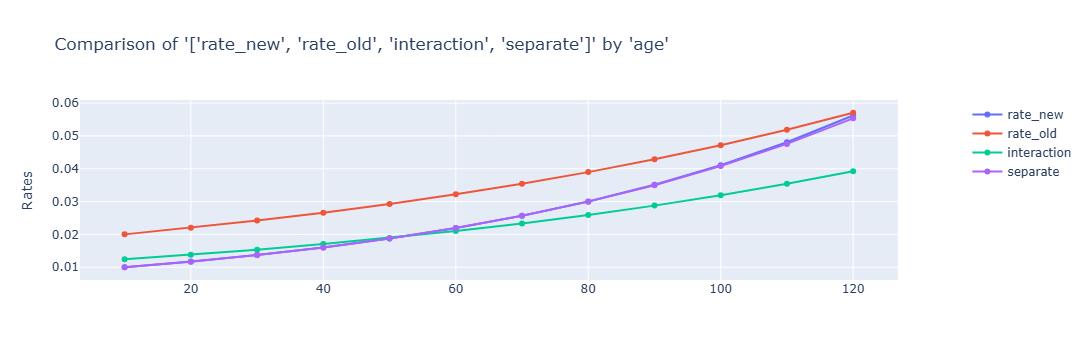

In [177]:
charters.compare_rates(
    merge_new,
    x_axis="age",
    rates=["rate_new", "rate_old", "interaction", "separate"],
)

In [178]:
new = full_data[(full_data["era"] == "new")][["era", "age", "rate"]]
old = full_data[(full_data["era"] == "old")]
merge_old = old.merge(new, how="left", on=["age"], suffixes=["_old", "_new"])

The old rate prediction are similar to actual for all predictions as there is sufficient data to train on. 

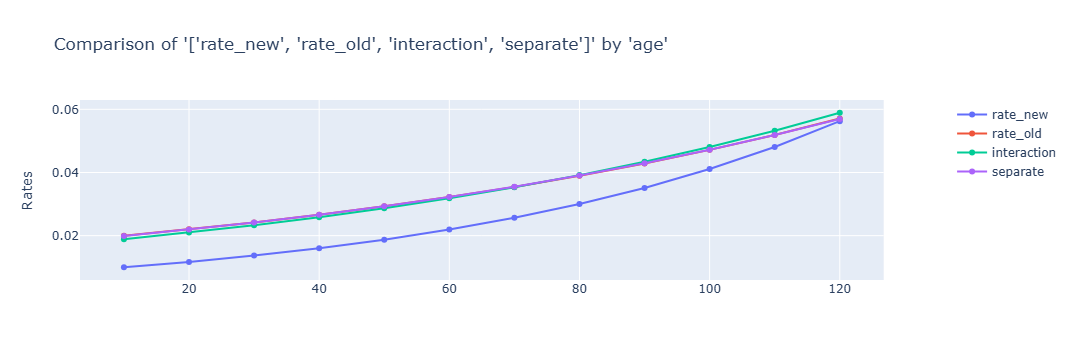

In [179]:
charters.compare_rates(
    merge_old,
    x_axis="age",
    rates=["rate_new", "rate_old", "interaction", "separate"],
)

## Historical Improvement

This is a simple example that is comparing between 2 scenarios. The test shows that it does not matter if you adjust before or after, but if using year in the variable, the variable would need to have the interactions to be accurate.
1. **rate:** historical experience *is not* adjusted for mortality improvment
2. **rate_adj:** historical *is* adjusted for mortality improvement

The assumptions are as follows:
- gender=1 has a mortality rate of 0.10 that decreases by .01 each year
- gender=0 has a mortality rate of 0.05 that decreases by .00 each year

In [189]:
model_data = pd.read_csv("tests/files/forecast/models/simple_data.csv")

In [190]:
model_data["year_gender"] = model_data["year"] * model_data["gender"]

In [191]:
forecast_list = [
    {
        "rate": "pred_rate",
        "feature_dict": {
            "target": ["rate"],
            "weight": [],
            "passthrough": ["year", "gender"],
        },
    },
    {
        "rate": "pred_rate_adj",
        "feature_dict": {
            "target": ["rate_adj"],
            "weight": [],
            "passthrough": ["gender"],
        },
    },
    {
        "rate": "pred_rate_gender",
        "feature_dict": {
            "target": ["rate"],
            "weight": [],
            "passthrough": ["gender"],
        },
    },
]

In [192]:
for forecast in forecast_list:
    feature_dict = forecast["feature_dict"]
    rate = forecast["rate"]
    preprocess_dict = preprocessors.preprocess_data(
        model_data, feature_dict=feature_dict, standardize=False, add_constant=True
    )

    X = preprocess_dict["X"]
    y = preprocess_dict["y"]
    weights = preprocess_dict["weights"]
    mapping = preprocess_dict["mapping"]

    GLM = core.GLM()
    GLM.fit(X, y, weights)

    # print(GLM.model.summary())

    predictions = GLM.model.predict(X)
    model_data[rate] = predictions

# charters.pdp(model=GLM.model, df=model_data, x_axis="gender", mapping=mapping)

 2025-12-20 12:23:21 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-20 12:23:21 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-20 12:23:21 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['gender', 'year', 'constant'] 
 2025-12-20 12:23:21 | morai.models.core | INFO     | fiting the model 
 2025-12-20 12:23:21 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C12E61B260> family... 
 2025-12-20 12:23:21 | morai.forecast.preprocessors | INFO     | model target: ['rate_adj'] 
 2025-12-20 12:23:21 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-20 12:23:21 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['gender', 'constant'] 
 2025-12-20 12:23:21 | morai.models.core | INFO     | fiting the model 
 2025-12-20 12:23:21 | morai.models

C:\Users\johnk\miniconda3\envs\morai\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning:

Perfect separation or prediction detected, parameter may not be identified

C:\Users\johnk\miniconda3\envs\morai\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning:

Perfect separation or prediction detected, parameter may not be identified



 2025-12-20 12:23:21 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-20 12:23:21 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-20 12:23:21 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['gender', 'constant'] 
 2025-12-20 12:23:21 | morai.models.core | INFO     | fiting the model 
 2025-12-20 12:23:21 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C12E61B260> family... 


As seen the blue line in the unadjusted rate and red line is the adjusted rate.
- **pred_rate_adj:** when predicting on gender after adjusting year rates are perfectly predicted with an as of date of 2010
- **pred_rate_gender:** when predicting on gender without adjusting year rates, it predicts the average mortality (midpoint) and would also be accurate, but with an as of date of 2014.5.
- **pred_rate:** when predicting on study year and gender and these variables interact, the resulting rates will be a blend and not accurate. The improvement will be the average of the genders.

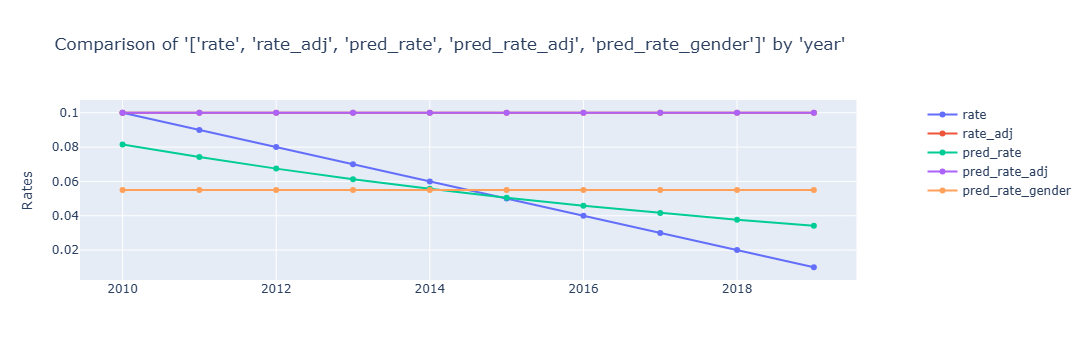

In [193]:
charters.compare_rates(
    model_data[model_data["gender"] == 1],
    x_axis="year",
    rates=["rate", "rate_adj", "pred_rate", "pred_rate_adj", "pred_rate_gender"],
)

## Weighting

This is a simple example compares a GLM when weighting vs. not weighting. This is important if you want the predictions to have more weight for a given data point.
1. **weighting**: this will produce a rate that is close to .9
2. **non-weighted**: this will produce a rate that is the average regardless of weight

There are 2 ways to weight in statmodels (`var_weights` and `freq_weights`). Currently using the `var_weights` method. This method does not replicate the exposures but rather gives each exposure more influence.

In [194]:
model_data = pd.read_csv("tests/files/forecast/models/simple_data_extreme.csv")

In [195]:
model_data

,record,expose,rate,actual
0,1,1000000,0.9,900000.0
1,1,1,0.1,0.1


In [196]:
X = model_data["record"]
y = model_data["rate"]
success = model_data["actual"]
failure = model_data["expose"] - model_data["actual"]
weights = model_data["expose"]

In [198]:
# weights
GLM = core.GLM()
GLM.fit(X, y, weights)
predictions = GLM.model.predict(X)
predictions

 2025-12-20 12:25:10 | morai.models.core | INFO     | fiting the model 
 2025-12-20 12:25:10 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C131FBB2F0> family... 


0    0.899999
1    0.899999
dtype: float64

In [199]:
# no weights
GLM = core.GLM()
GLM.fit(X, y)
predictions = GLM.model.predict(X)
predictions

 2025-12-20 12:25:17 | morai.models.core | INFO     | fiting the model 
 2025-12-20 12:25:17 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C131FBB2F0> family... 


0    0.5
1    0.5
dtype: float64

In [200]:
# weights with success failures
GLM = core.GLM()
GLM.fit(X, pd.concat([success, failure], axis=1))
predictions = GLM.model.predict(X)
predictions

 2025-12-20 12:25:42 | morai.models.core | INFO     | fiting the model 
 2025-12-20 12:25:42 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C131FC2B70> family... 


0    0.899999
1    0.899999
dtype: float64

### Frequency vs. Variance Weighted

There was no difference between the predictions of the `freq_weights` and `var_weights`, however the number of residuals do change substantially. Due to using binomial distribution is also the reason as well.

In [203]:
# frequency weights
glm_freq = sm.GLM(
    endog=y, exog=X, family=sm.families.Binomial(), freq_weights=weights
).fit()
print(glm_freq.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   rate   No. Observations:                    2
Model:                            GLM   Df Residuals:                  1000000
Model Family:                Binomial   Df Model:                            0
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.3623e+05
Date:                Sat, 20 Dec 2025   Deviance:                       3.5156
Time:                        12:26:21   Pearson chi2:                     7.11
No. Iterations:                     6   Pseudo R-squ. (CS):         -8.731e-10
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
record         2.1972      0.003    659.167      0.0

In [204]:
# variance weights
glm_var = sm.GLM(
    endog=y, exog=X, family=sm.families.Binomial(), var_weights=weights
).fit()
print(glm_var.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   rate   No. Observations:                    2
Model:                            GLM   Df Residuals:                        1
Model Family:                Binomial   Df Model:                            0
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.3623e+05
Date:                Sat, 20 Dec 2025   Deviance:                       3.5156
Time:                        12:26:22   Pearson chi2:                     7.11
No. Iterations:                     6   Pseudo R-squ. (CS):         -8.731e-10
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
record         2.1972      0.003    659.167      0.0

In [205]:
model_data["qx_glm_freq"] = glm_freq.predict(X)
model_data["qx_glm_var"] = glm_var.predict(X)

In [206]:
model_data

,record,expose,rate,actual,qx_glm_freq,qx_glm_var
0,1,1000000,0.9,900000.0,0.899999,0.899999
1,1,1,0.1,0.1,0.899999,0.899999


## Credibility

### Importance

A basis of Buhlmann credibility is:
   - large number of observations -> increased credibility
   - mean of the hypothetical variances is small (EPV) -> increased credibility
   - variances of the mean are large (VHM) -> increased credibility

The formula is: $$\frac{N}{N + \left(\frac{\text{EPV}}{\text{VHM}}\right)}$$

A good example of this is a dartboard. If all the shots are clustered in distinct areas the mean of variances (EPV) are small. If the mean of those clusters are large the variance is larger (VHM).

Taking this in context of a logistic regression that differs by many features the credibility should be influenced by some features. Here are a few comments on those influences:

   - The most important features will have the largest influence on the rate. For example, for a mortality rate, attained age will have a larger influence than sex.
   - The larger the factor is for the rate the more important the function would be as well.



In [233]:
blend = pd.read_csv("tests/files/experience/blend_credibility.csv")

In [234]:
preprocess_dict = preprocessors.preprocess_data(
    blend,
    feature_dict={
        "target": ["rate"],
        "weight": ["exposure"],
        "passthrough": ["age", "sex", "risk", "sub", "rare"],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

 2025-12-20 18:10:01 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-20 18:10:01 | morai.forecast.preprocessors | INFO     | model weights: ['exposure'] 
 2025-12-20 18:10:01 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-20 18:10:02 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['sex', 'age', 'risk', 'sub', 'rare', 'constant'] 


When reviewing the features that contribute to the reduction in deviance it can be seen that age is the largest contributing feature, followed by risk and sub.

In [236]:
GLM = core.GLM()
GLM.get_feature_contributions(X, y, weights=weights, base_features=[])

 2025-12-20 18:10:29 | morai.models.core | INFO     | generating feature contributions from model for 5 features by fitting the model and seeing the reduction in deviance. 
 2025-12-20 18:10:29 | morai.models.core | INFO     | base features: '['constant']' 


,features,contribution,deviance
0,all,1.000000,55.056802
1,base,0.000000,1348.303719
2,age,0.883406,1197.518804
3,rare,0.015468,75.060252
4,risk,0.048178,117.363459
5,sex,0.001138,56.528463
6,sub,0.048178,117.363459


The `rare` feature will be more influential to rates than the `sub` as there is a large difference in the scalar.

In [210]:
GLM.get_odds()

 2025-12-20 12:29:30 | morai.models.core | INFO     | generating odds ratio from model 


rare        0.000404
risk        0.794471
sex         0.795323
sub         0.794471
age         1.036657
constant    0.002209
dtype: float64

### Grouping

When generating predictions, generally the data will be trained on granular information. The data that is being predicted on using GLMs, does generate a smooth line through the actuals so the data from nearby cells would influence the overall curve. 

When reviewing credibility, it is worth thinking about if the credibility of a cell should group ages together. The predictions would not be very different if training was done using the grouped ages.

Below example compares predicting mortality using `individual` ages vs. using `grouped` quintennial ages. It should be noted that the grouping did use a midpoint age so that model could still predict individual ages.

In [327]:
sigmoid = pd.read_csv("tests/files/forecast/models/sigmoid_data.csv")

In [328]:
sigmoid["binned_age"] = preprocessors.bin_feature(sigmoid["age"], 24, labels="midpoint")

In [331]:
feature_dict = {
    "target": ["rate"],
    "weight": ["weight"],
    "passthrough": ["age", "faceband", "gender", "binned_age"],
    "ordinal": [],
    "ohe": [],
    "nominal": [],
}

In [332]:
preprocess_dict = preprocessors.preprocess_data(
    sigmoid,
    feature_dict=feature_dict,
    standardize=False,
    add_constant=True,
)

 2025-12-21 00:10:28 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-12-21 00:10:28 | morai.forecast.preprocessors | INFO     | model weights: ['weight'] 
 2025-12-21 00:10:28 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-21 00:10:28 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'faceband', 'gender', 'binned_age', 'constant'] 


In [333]:
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]
md_encoded = preprocess_dict["md_encoded"]
model_features = preprocess_dict["model_features"]

In [334]:
GLM = core.GLM()

In [335]:
GLM.get_feature_contributions(
    X[["constant", "faceband", "gender", "binned_age"]],
    y,
    weights=weights,
    base_features=[],
)

 2025-12-21 00:10:30 | morai.models.core | INFO     | generating feature contributions from model for 3 features by fitting the model and seeing the reduction in deviance. 
 2025-12-21 00:10:30 | morai.models.core | INFO     | base features: '['constant']' 


,features,contribution,deviance
0,all,1.00000,391.651107
1,base,0.00000,25998.089654
2,faceband,0.01668,818.744634
3,gender,0.00000,391.651107
4,binned_age,0.99677,25915.315058


In [337]:
# rate binned
GLM.fit(
    X=X[["constant", "faceband", "gender", "binned_age"]],
    y=y,
    weights=weights,
)
sigmoid["rate_binned"] = GLM.model.predict(X[["constant", "faceband", "gender", "age"]])

# rate non-binned
GLM.fit(
    X=X[["constant", "faceband", "gender", "age"]],
    y=y,
    weights=weights,
)
sigmoid["rate_nonbinned"] = GLM.model.predict(
    X[["constant", "faceband", "gender", "age"]]
)

 2025-12-21 00:10:33 | morai.models.core | INFO     | fiting the model 
 2025-12-21 00:10:33 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C083293020> family... 
 2025-12-21 00:10:33 | morai.models.core | INFO     | fiting the model 
 2025-12-21 00:10:33 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C0832E2270> family... 


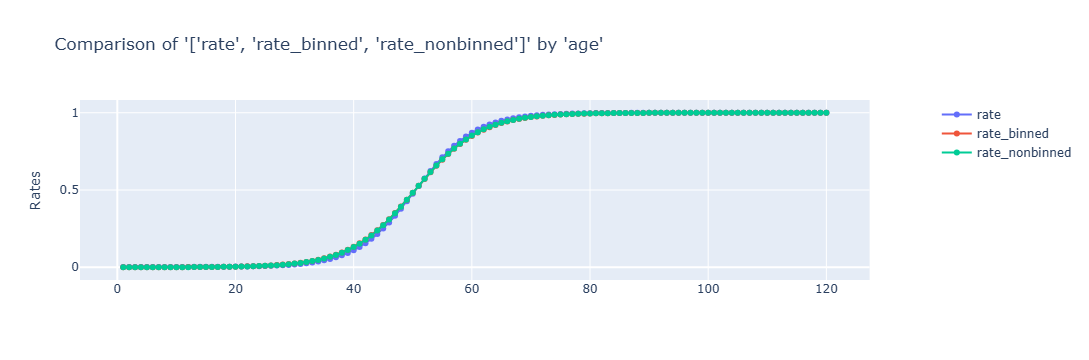

In [338]:
charters.compare_rates(
    sigmoid[(sigmoid["gender"] == 0) & (sigmoid["faceband"] == 1)],
    x_axis="age",
    rates=["rate", "rate_binned", "rate_nonbinned"],
)

## Feature Engineering

There is some art to creating models that fit the actuals correctly. This section reviews feature development.

A different combination of the following features are considered.
- age
- age squared
- age squareroot

Finding the right balance is helpful. Reviewing the results it was shown that `age` by itself did not capture increasing at a decreasing rate shape of the actuals. The `age squared` was able to put more weight on the older ages and had a shape more similar to the actuals. `age squareroot` did also help the shape.

In [103]:
full_data = pd.read_csv("notebooks/files/simple_data_features.csv")
full_data = full_data[["era", "age", "rate"]]
model_data = full_data.copy()
model_data["age_sqrd"] = model_data["age"] ** 2
model_data["age_sqrt"] = model_data["age"] ** 0.5

In [104]:
# [age]
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict={
        "target": ["rate"],
        "weight": [],
        "passthrough": [
            "age",
        ],
    },
    standardize=False,
    add_constant=True,
)
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

# model the data
GLM = core.GLM()
GLM.fit(X, y)
model_data["pred_age"] = GLM.model.predict(X)

 2025-11-27 12:16:33 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:16:33 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:16:33 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'constant'] 
 2025-11-27 12:16:33 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:16:33 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE7075C860> family... 


In [105]:
# [age, age_sqrd]
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict={"target": ["rate"], "weight": [], "passthrough": ["age", "age_sqrd"]},
    standardize=False,
    add_constant=True,
)
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

# model the data
GLM = core.GLM()
GLM.fit(X, y)
model_data["pred_age_age_sqrd"] = GLM.model.predict(X)

 2025-11-27 12:16:36 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:16:36 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:16:36 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age_sqrd', 'age', 'constant'] 
 2025-11-27 12:16:36 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:16:36 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE717F41D0> family... 


In [106]:
# [age, age_sqrt, age_sqrd]
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict={
        "target": ["rate"],
        "weight": [],
        "passthrough": ["age", "age_sqrd", "age_sqrt"],
    },
    standardize=False,
    add_constant=True,
)
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

# model the data
GLM = core.GLM()
GLM.fit(X, y)
model_data["pred_age_age_sqrt_age_sqrd"] = GLM.model.predict(X)

 2025-11-27 12:16:39 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:16:39 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:16:39 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age_sqrt', 'age_sqrd', 'age', 'constant'] 
 2025-11-27 12:16:39 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:16:39 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE7186DEE0> family... 


In [107]:
# [age, age_sqrt]
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict={
        "target": ["rate"],
        "weight": [],
        "passthrough": ["age", "age_sqrt"],
    },
    standardize=False,
    add_constant=True,
)
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

# model the data
GLM = core.GLM()
GLM.fit(X, y)
model_data["pred_age_age_sqrt"] = GLM.model.predict(X)

 2025-11-27 12:16:40 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-11-27 12:16:40 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 12:16:40 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age_sqrt', 'age', 'constant'] 
 2025-11-27 12:16:40 | morai.models.core | INFO     | fiting the model 
 2025-11-27 12:16:40 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002CE7186DEE0> family... 


In [109]:
charters.compare_rates(
    model_data,
    x_axis="age",
    rates=[
        "rate",
        "pred_age",
        "pred_age_age_sqrd",
        "pred_age_age_sqrt_age_sqrd",
        "pred_age_age_sqrt",
    ],
)

## Residual Analysis

When analyzing the fit of a model, one method to review is to see if the variance of residuals are normal. It is expected that the difference between actuals and predictions should be both negative and positive with some normality.

There were a few methods used.
- **qq plot:** compares the residual distribution vs a known distribution (such as normal). This could identify fatter or skinnier tails.
- **scatter plot:** a scatter plot can help inform if a model has a trend in residuals vs the fitted predictions. The `deviance` parameter is non-standardized residual while `pearson` is the standardized residual. A way to think about pearson would be standardized z-scores.
- **dispersion**: dispersion rescales variance the model assumes to what the data shows
- **residual plot**: measures the residual interval compared to the fitted value. Values higher than 0 correspond to underpredicting.
- **calibration plot**: compares the observed to the fitted values. Values higher than the 45 degree line correspond to underpredicting. The residual and calibration plots have similar observation.

There are several residual analysis terms that are worth noting here:
  - **deviance**: this is the spread in likelihood. It describes the likelihood of a perfect model vs likelihood of the fitted model.
$$D_{general} = 2\left[\ell(\text{saturated}) - \ell(\text{fitted})\right] = \sum_{i=1}^{n} r_{i,D}^{2}$$
$$
D_{binomial}
= 2\sum_{i=1}^{n}
\left[
y_i \log\!\left(\frac{y_i}{\hat{p}_i}\right)
+ (1-y_i)\log\!\left(\frac{1-y_i}{1-\hat{p}_i}\right)
\right]
$$
  - **dispersion**: this is the variance in the model compared to what it is expected to be.
$$
\hat{\phi} = \frac{
\sum_{i} w_i \, (y_i - \hat{\mu}_i)^2 \,/\, V(\hat{\mu}_i)
}{
\mathrm{df}_r
} = \frac{\mathrm{PearsonDeviance}}{\mathrm{df}_r}
$$
  - **standard error (SE)**: this is the noise in the estimate, which is proportional to amount of data.
$$
\operatorname{SE} = \frac{\sigma}{\sqrt{n}}
$$

Since GLM is minimizing deviance while OLS minimizes the sum of squares. Relationships of the two can be seen below.
  - Residual sum of squares ~ Deviance
  - Variance ~ Dispersion (Deviation / Degrees of Freedom)
  - Standard Deviation ~ sqrt(Dispersion)

In [990]:
from morai.integrations import hmd

db_filepath = r"files/integrations/hmd/hmd.sql"
hmd_usa_df = hmd.get_hmd_data_sql(db_filepath=db_filepath, table_name="hmd")
hmd_usa_df = hmd_usa_df[(hmd_usa_df["year"] >= 1950) & (hmd_usa_df["year"] <= 2023)]
hmd_usa_df["qx_raw"] = hmd_usa_df["total_death"] / hmd_usa_df["total_exposure"]

In [1025]:
preprocess_dict = preprocessors.preprocess_data(
    hmd_usa_df,
    feature_dict={
        "target": ["qx_raw"],
        "weight": ["total_exposure"],
        "passthrough": [
            "year",
            "age",
        ],
    },
    standardize=True,
    add_constant=True,
)

X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

 2026-01-01 18:06:33 | morai.forecast.preprocessors | INFO     | model target: ['qx_raw'] 
 2026-01-01 18:06:33 | morai.forecast.preprocessors | INFO     | model weights: ['total_exposure'] 
 2026-01-01 18:06:33 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2026-01-01 18:06:33 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'year', 'constant'] 
 2026-01-01 18:06:33 | morai.forecast.preprocessors | INFO     | standardizing the data with StandardScaler 


In [1026]:
GLM = core.GLM()
GLM.fit(X, y, weights)
predictions = GLM.predict(X)

hmd_usa_df = experience.calc_qx_exp_ae(
    model_data=hmd_usa_df,
    predictions=predictions,
    model_name="glm",
    exposure_col="total_exposure",
    actual_col="total_death",
)

 2026-01-01 18:06:34 | morai.models.core | INFO     | fiting the model with 3 features 
 2026-01-01 18:06:34 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C08FC29D00> family... 


In [1027]:
residuals = pd.DataFrame(
    {
        "deviance": GLM.model.resid_deviance,
        "pearson": GLM.model.resid_pearson,
        "fitted": GLM.model.fittedvalues,
    }
)

The below shows a pretty good fit of standardized residuals. The higher quantiles show that the residuals are showing a heavier tail than a normal distribution would expect.

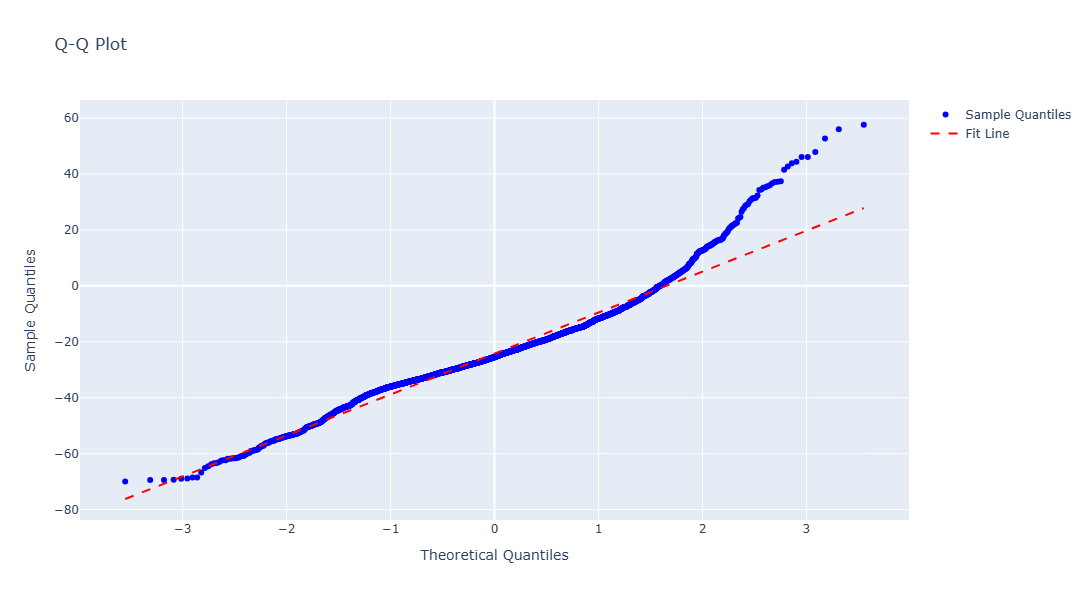

In [1031]:
mask = (X["age"] > mapping["age"]["values"][30]) & (
    X["age"] < mapping["age"]["values"][80]
)
charters.qq(residuals[mask]["pearson"])

There is generally a good pattern or residuals however a slight trend upward. The magnitude is large, however that is due to the variance being too small for the data being modeled. The A/E should be considered a better diagnotistic for fit.

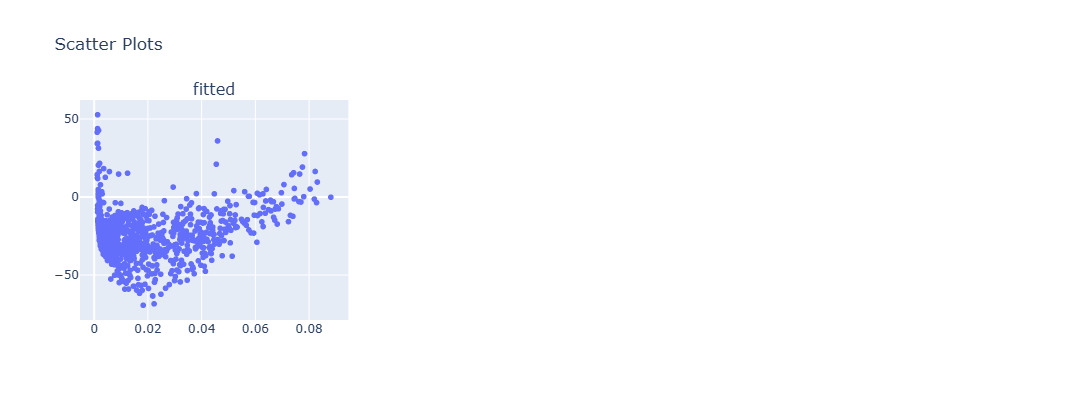

In [1029]:
charters.scatter(
    residuals[mask], target="pearson", features=["fitted"], sample_nbr=1000
)

Expected to have a dispersion of 1, which highlights that the model has areas of high residuals.

In [1013]:
GLM.calculate_dispersion(residuals=residuals["pearson"][mask])

np.float64(810.283747728882)

The pearson residuals show that the predictions overestimate in general.

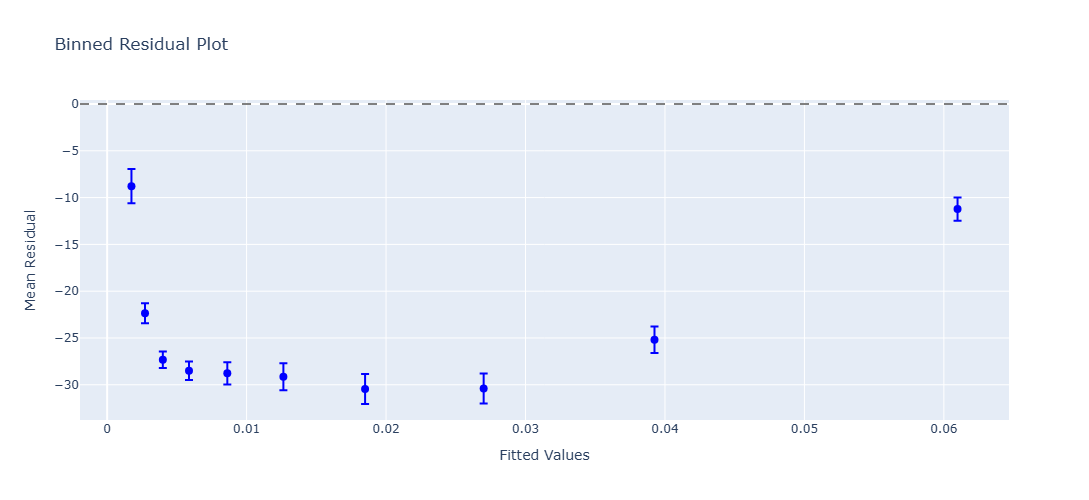

In [1017]:
charters.residual_plot(
    fitted=residuals["fitted"][mask], residuals=residuals["pearson"][mask], n_bins=10
)

The above observation can also be seen in the calibration plot.

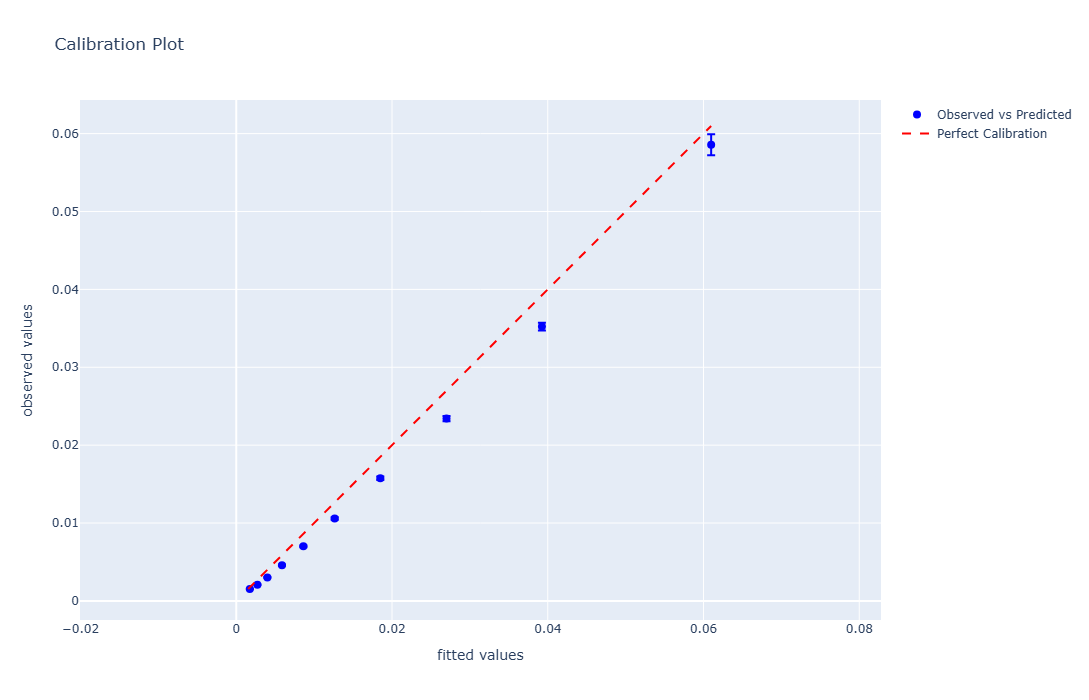

In [999]:
charters.calibration_plot(
    fitted=residuals["fitted"][mask],
    observed=GLM.model.model.endog[mask],
    n_bins=10,
    log=False,
)

It should be noted that the GLM is fitting where there is the most data generally in 60-80 age range, but doesn't fit well at the tails.

 2026-01-01 18:04:32 | morai.experience.charters | INFO     | The weights list is 1 long and should be 2 long. Using the first weight for all weights. 


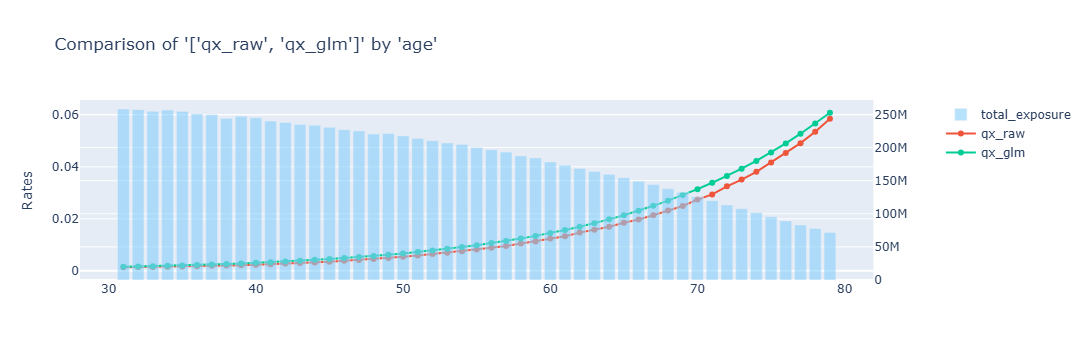

In [1024]:
charters.compare_rates(
    hmd_usa_df[mask],
    x_axis="age",
    rates=["qx_raw", "qx_glm"],
    weights=["total_exposure"],
    secondary="total_exposure",
    # y_log=True,
)

## Penalized Model

There are cases when a model can be overfit and the coefficients can be too much. To address this a model can be penalized.

- **Ridge (L2)**: This method mutes the impact of some of the coefficients
- **Lasso (L1)**: This method excludes coefficients that are not as impactful
- **Elastic Net**: This is a combination of both that mixes the L1 and L2 penalties

A parameter `alpha` controls the strength of the penalization, with higher values having higher penalty.

Penalized models should use **standardization** of features so that coefficients aren't outweighing eachother.

In [1003]:
from morai.integrations import hmd

db_filepath = r"files/integrations/hmd/hmd.sql"
hmd_usa_df = hmd.get_hmd_data_sql(db_filepath=db_filepath, table_name="hmd")
hmd_usa_df = hmd_usa_df[(hmd_usa_df["year"] >= 1950) & (hmd_usa_df["year"] <= 2023)]
hmd_usa_df["qx_raw"] = hmd_usa_df["total_death"] / hmd_usa_df["total_exposure"]

In [1006]:
preprocess_dict = preprocessors.preprocess_data(
    hmd_usa_df,
    feature_dict={
        "target": ["qx_raw"],
        "weight": ["total_exposure"],
        "passthrough": [
            "year",
            "age",
        ],
    },
    standardize=True,
    add_constant=True,
)

X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

 2026-01-01 17:44:03 | morai.forecast.preprocessors | INFO     | model target: ['qx_raw'] 
 2026-01-01 17:44:03 | morai.forecast.preprocessors | INFO     | model weights: ['total_exposure'] 
 2026-01-01 17:44:03 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2026-01-01 17:44:03 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'year', 'constant'] 
 2026-01-01 17:44:03 | morai.forecast.preprocessors | INFO     | standardizing the data with StandardScaler 


In [1007]:
GLM = core.GLM()
res = GLM.fit(X, y, weights)
predictions = GLM.predict(X)

hmd_usa_df = experience.calc_qx_exp_ae(
    model_data=hmd_usa_df,
    predictions=predictions,
    model_name="glm",
    exposure_col="total_exposure",
    actual_col="total_death",
)

 2026-01-01 17:44:03 | morai.models.core | INFO     | fiting the model with 3 features 
 2026-01-01 17:44:03 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C090FC6A20> family... 


In [1008]:
# ridge
GLM = core.GLM()
res = GLM.fit(X, y, weights, l1_wt=0, alpha=0.001)
predictions = GLM.predict(X)

hmd_usa_df = experience.calc_qx_exp_ae(
    model_data=hmd_usa_df,
    predictions=predictions,
    model_name="glm_ridge",
    exposure_col="total_exposure",
    actual_col="total_death",
)

 2026-01-01 17:44:04 | morai.models.core | INFO     | fiting the model with 3 features 
 2026-01-01 17:44:04 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C090780C50> family... 
 2026-01-01 17:44:04 | morai.models.core | INFO     | fitting penalized GLM with alpha=0.001, L1_wt=0 


In [1009]:
# lasso
GLM = core.GLM()
res = GLM.fit(
    X,
    y,
    weights,
    l1_wt=1,
    alpha=0.001,
    maxiter=1000,
)
predictions = GLM.predict(X)

hmd_usa_df = experience.calc_qx_exp_ae(
    model_data=hmd_usa_df,
    predictions=predictions,
    model_name="glm_lasso",
    exposure_col="total_exposure",
    actual_col="total_death",
)

 2026-01-01 17:44:06 | morai.models.core | INFO     | fiting the model with 3 features 
 2026-01-01 17:44:06 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C090781310> family... 
 2026-01-01 17:44:06 | morai.models.core | INFO     | fitting penalized GLM with alpha=0.001, L1_wt=1 


 2026-01-01 17:44:23 | morai.experience.charters | INFO     | The weights list is 1 long and should be 4 long. Using the first weight for all weights. 


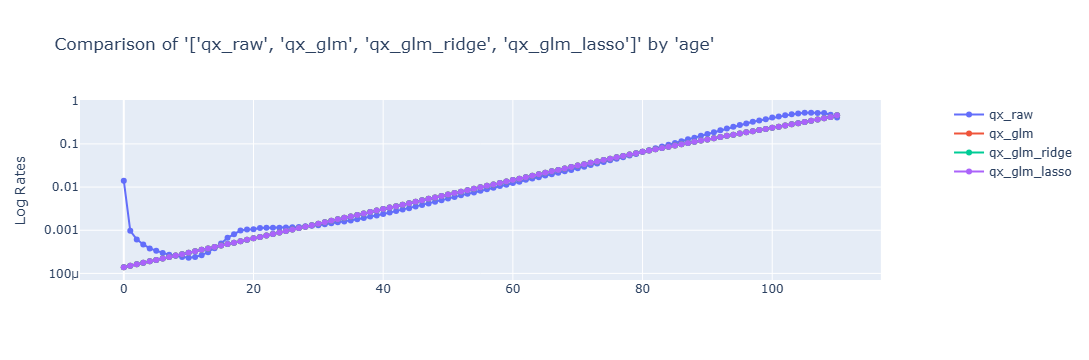

In [1011]:
charters.compare_rates(
    hmd_usa_df,
    x_axis="age",
    rates=["qx_raw", "qx_glm", "qx_glm_ridge", "qx_glm_lasso"],
    weights=["total_exposure"],
    y_log=True,
)

## Poisson vs. Binomial

A poisson and binomial model have different structures as a distribution. When the p is small these distributions are similar. 

- **binomial**: has mean = n * p and variance = n * p * (1 - p)
- **poisson**: has mean = λ and variance = λ

In [873]:
from morai.integrations import hmd

db_filepath = r"files/integrations/hmd/hmd.sql"
hmd_usa_df = hmd.get_hmd_data_sql(db_filepath=db_filepath, table_name="hmd")
hmd_usa_df = hmd_usa_df[(hmd_usa_df["year"] >= 1950) & (hmd_usa_df["year"] <= 2023)]
hmd_usa_df["qx_raw"] = hmd_usa_df["total_death"] / hmd_usa_df["total_exposure"]

In [874]:
# binomial
preprocess_dict = preprocessors.preprocess_data(
    hmd_usa_df,
    feature_dict={
        "target": ["qx_raw"],
        "weight": ["total_exposure"],
        "passthrough": [
            "year",
            "age",
        ],
    },
    standardize=True,
    add_constant=True,
)

X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

 2025-12-31 16:46:41 | morai.forecast.preprocessors | INFO     | model target: ['qx_raw'] 
 2025-12-31 16:46:41 | morai.forecast.preprocessors | INFO     | model weights: ['total_exposure'] 
 2025-12-31 16:46:41 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-12-31 16:46:41 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'year', 'constant'] 
 2025-12-31 16:46:41 | morai.forecast.preprocessors | INFO     | standardizing the data with StandardScaler 
 2025-12-31 16:46:41 | morai.forecast.preprocessors | INFO     | standardizing the weights by dividing by the mean 


In [875]:
GLM = core.GLM()
GLM.fit(X, y, weights)
predictions = GLM.predict(X)

hmd_usa_df = experience.calc_qx_exp_ae(
    model_data=hmd_usa_df,
    predictions=predictions,
    model_name="binomial",
    exposure_col="total_exposure",
    actual_col="total_death",
)

 2025-12-31 16:46:43 | morai.models.core | INFO     | fiting the model with 3 features 
 2025-12-31 16:46:43 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x000002C090CE77A0> family... 


In [945]:
# poisson
preprocess_dict = preprocessors.preprocess_data(
    hmd_usa_df,
    feature_dict={
        "target": ["total_death"],
        "weight": ["total_exposure"],
        "passthrough": [
            "year",
            "age",
        ],
    },
    standardize=True,
    add_constant=True,
)

X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

 2026-01-01 16:51:29 | morai.forecast.preprocessors | INFO     | model target: ['total_death'] 
 2026-01-01 16:51:30 | morai.forecast.preprocessors | INFO     | model weights: ['total_exposure'] 
 2026-01-01 16:51:30 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2026-01-01 16:51:30 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'year', 'constant'] 
 2026-01-01 16:51:30 | morai.forecast.preprocessors | INFO     | standardizing the data with StandardScaler 


In [946]:
GLM = core.GLM()
GLM.fit(X, y, family=sm.families.Poisson(), offset=np.log(weights))
predictions = GLM.predict(X)

hmd_usa_df = experience.calc_qx_exp_ae(
    model_data=hmd_usa_df,
    predictions=predictions,
    model_name="poisson",
    exposure_col="total_exposure",
    actual_col="total_death",
)

 2026-01-01 16:51:30 | morai.models.core | INFO     | fiting the model with 3 features 
 2026-01-01 16:51:30 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Poisson object at 0x000002C08FAA0920> family... 


In [971]:
residuals = pd.DataFrame(
    {
        "deviance": GLM.model.resid_deviance,
        "pearson": GLM.model.resid_pearson,
        "fitted": GLM.model.fittedvalues,
    }
)

The below shows how overdispersion happens in actuarial mortality modeling.

In [972]:
import math
(f"In cell 10065 the actual death was {hmd_usa_df.loc[10065]['total_death']:,.2f} and the poisson predicted death "
f"was {hmd_usa_df.loc[10065]['exp_amt_poisson']:,.2f}. This has a standard deviation of sqrt(u) = "
f"{math.sqrt(hmd_usa_df.loc[10065]['exp_amt_poisson']):,.2f}. The approximate residual is (y - u) / sd = "
f"{(hmd_usa_df.loc[10065]['total_death'] - hmd_usa_df.loc[10065]['exp_amt_poisson']) / math.sqrt(hmd_usa_df.loc[10065]['exp_amt_poisson']):,.2f}."
f" This shows that although the prediction was fairly accurate the standard deviation was too small likely related to other features not being modeled.")

'In cell 10065 the actual death was 78,593.06 and the poisson predicted death was 93,124.94. This has a standard deviation of sqrt(u) = 305.16. The approximate residual is (y - u) / sd = -47.62. This shows that although the prediction was fairly accurate the standard deviation was too small likely related to other features not being modeled.'

In [974]:
(f"Similarly for binomial, in cell 10065 the actual death was {hmd_usa_df.loc[10065]['total_death']:,.2f} and the binomial predicted death "
f"was {hmd_usa_df.loc[10065]['exp_amt_binomial']:,.2f}. This has a standard deviation of sqrt(n * u * (1-u)) = "
f"{math.sqrt(hmd_usa_df.loc[10065]['total_exposure']*hmd_usa_df.loc[10065]['qx_binomial']*(1-hmd_usa_df.loc[10065]['qx_binomial'])):,.2f}. The approximate residual is (y - u) / sd = "
f"{(hmd_usa_df.loc[10065]['total_death'] - hmd_usa_df.loc[10065]['exp_amt_binomial']) / math.sqrt(hmd_usa_df.loc[10065]['total_exposure']*hmd_usa_df.loc[10065]['qx_binomial']*(1-hmd_usa_df.loc[10065]['qx_binomial'])):,.2f}."
f" This shows that although the prediction was fairly accurate the standard deviation was too small likely related to other features not being modeled.")

'Similarly for binomial, in cell 10065 the actual death was 78,593.06 and the binomial predicted death was 95,150.91. This has a standard deviation of sqrt(n * u * (1-u)) = 303.29. The approximate residual is (y - u) / sd = -54.59. This shows that although the prediction was fairly accurate the standard deviation was too small likely related to other features not being modeled.'

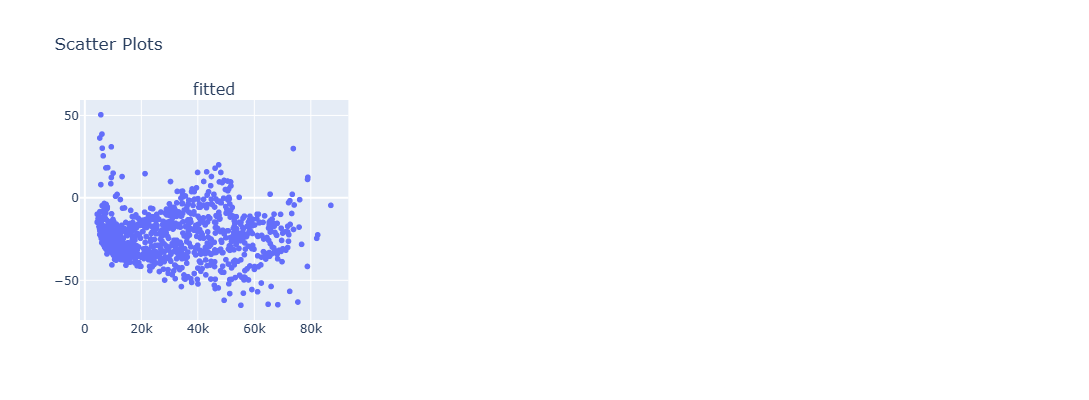

In [927]:
charters.scatter(
    residuals[mask], target="pearson", features=["fitted"], sample_nbr=1000
)

In [928]:
GLM.calculate_dispersion(residuals=residuals[mask]["pearson"])

np.float64(732.9153081307203)

## Test

In [635]:
helpers.memory_usage_jupyter()

,object,size_mb
0,grouped_df,233.844976
1,model_data,2.882751
2,hmd_usa_df,2.882751
3,X,0.250702
4,residuals,0.250702
...,...,...
130,sex,0.000027
131,initial_row_count,0.000027
132,n,0.000027
133,n_bins,0.000027


In [636]:
helpers.memory_usage_jupyter_cells("glm.ipynb")

 2025-12-25 17:27:24 | morai.utils.helpers | INFO     | getting largest cells for C:\Users\johnk\Desktop\github\morai\notebooks\tutorials\glm.ipynb 


,cell_idx,cell_type,size_kb,preview
117,117,code,416.4,"mask = (X[""age""] > 30) & (X[""age""] < 80) chart..."
119,119,code,112.8,"charters.scatter( residuals[mask], target=..."
56,56,code,98.0,"charters.compare_rates( merge_new, x_a..."
59,59,code,88.7,"charters.compare_rates( merge_old, x_a..."
67,67,code,87.5,charters.compare_rates( model_data[model_d...
136,136,code,85.7,"charters.compare_rates( hmd_usa_df, x_..."
37,37,code,84.2,"charters.compare_rates( merge_new, x_a..."
126,126,code,82.0,"charters.compare_rates( hmd_usa_df[mask], ..."
101,101,code,79.6,"charters.compare_rates( sigmoid[(sigmoid[""..."
47,47,code,77.1,"fast = full_data[ (full_data[""speed""] == ""..."
